# Reinforcement Learning for trading

To train a trading agent, we need to create a market environment that provides price and other information, offers trading-related actions, and keeps track of the portfolio to reward the agent accordingly.

## How to Design an OpenAI trading environment

The OpenAI Gym allows for the design, registration, and utilization of environments that adhere to its architecture, as described in its [documentation](https://github.com/openai/gym/tree/master/gym/envs#how-to-create-new-environments-for-gym). The [trading_env.py](trading_env.py) file implements an example that illustrates how to create a class that implements the requisite `step()` and `reset()` methods.

The trading environment consists of three classes that interact to facilitate the agent's activities:
 1. The `DataSource` class loads a time series, generates a few features, and provides the latest observation to the agent at each time step. 
 2. `TradingSimulator` tracks the positions, trades and cost, and the performance. It also implements and records the results of a buy-and-hold benchmark strategy. 
 3. `TradingEnvironment` itself orchestrates the process. 

## A basic trading game

To train the agent, we need to set up a simple game with a limited set of options, a relatively low-dimensional state, and other parameters that can be easily modified and extended.

More specifically, the environment samples a stock price time series for a single ticker using a random start date to simulate a trading period that, by default, contains 252 days, or 1 year. The state contains the (scaled) price and volume, as well as some technical indicators like the percentile ranks of price and volume, a relative strength index (RSI), as well as 5- and 21-day returns. The agent can choose from three actions:

- **Buy**: Invest capital for a long position in the stock
- **Flat**: Hold cash only
- **Sell short**: Take a short position equal to the amount of capital

The environment accounts for trading cost, which is set to 10bps by default. It also deducts a 1bps time cost per period. It tracks the net asset value (NAV) of the agent's portfolio and compares it against the market portfolio (which trades frictionless to raise the bar for the agent).

We use the same DDQN agent and neural network architecture that successfully learned to navigate the Lunar Lander environment. We let exploration continue for 500,000 time steps (~2,000 1yr trading periods) with linear decay of ε to 0.1 and exponential decay at a factor of 0.9999 thereafter.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
from pathlib import Path
from time import time,localtime,strftime
from collections import deque
from random import sample

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam # .legacy
from tensorflow.keras.regularizers import l2

import gymnasium as gym
from gymnasium.envs.registration import register
# tf.keras.utils.disable_interactive_logging()

In [3]:
print('tf ->',tf.__version__)
print('gym ->',gym.__version__)

tf -> 2.15.0
gym -> 0.29.1


In [4]:
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
sns.set_style('whitegrid')

In [6]:
tf.config.set_visible_devices([], 'GPU')

In [7]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU...')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU...')

Using GPU...


In [8]:
results_path = Path('results', 'trading_bot')
if not results_path.exists():
    results_path.mkdir(parents=True)

### Helper functions

In [9]:
def format_time(t):
    m_,s = divmod(t, 60)
    h, m = divmod(m_, 60)
    return '{:02.0f}:{:02.0f}:{:02.0f}'.format(h, m, s)

## Set up Gym Environment

Before using the custom environment, just like we used the Lunar Lander environment, we need to register it:

In [10]:
trading_days = 252 # 252

In [11]:
register(
    id='trading-v0',
    entry_point='trading_env:TradingEnvironment',
    max_episode_steps=trading_days
)

### Initialize Trading Environment

We can instantiate the environment by using the desired trading costs and ticker:

In [12]:
trading_environment = gym.make('trading-v0',trading_days=trading_days)
trading_environment.env.trading_days = trading_days
trading_environment.env.trading_cost_bps = 1e-4 # 1e-3
trading_environment.env.time_cost_bps = 1e-5    # 1e-4
trading_environment.env.ticker = 'AAPL'
#trading_environment.seed(42)

INFO:trading_env:trading_env logger started.
INFO:trading_env:loading data for AAPL...
INFO:trading_env:got data for AAPL...
INFO:trading_env:None


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9367 entries, (Timestamp('1981-01-30 00:00:00'), 'AAPL') to (Timestamp('2018-03-27 00:00:00'), 'AAPL')
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   returns  9367 non-null   float64
 1   ret_2    9367 non-null   float64
 2   ret_5    9367 non-null   float64
 3   ret_10   9367 non-null   float64
 4   ret_21   9367 non-null   float64
 5   rsi      9367 non-null   float64
 6   macd     9367 non-null   float64
 7   atr      9367 non-null   float64
 8   stoch    9367 non-null   float64
 9   ultosc   9367 non-null   float64
dtypes: float64(10)
memory usage: 1.5+ MB


In [13]:
#trading_environment.data_source.data = \
#    trading_environment.data_source.data.loc[('2011-01-01', 'AAPL'):]

### Get Environment Params

In [14]:
state_dim = trading_environment.observation_space.shape[0]
num_actions = trading_environment.action_space.n
max_episode_steps = trading_environment.spec.max_episode_steps
state_dim, num_actions, max_episode_steps

(10, 3, 252)

## Define Trading Agent

In [15]:
class DDQNAgent:
    def __init__(self, state_dim,
                 num_actions,
                 learning_rate,
                 gamma,
                 epsilon_start,
                 epsilon_end,
                 epsilon_decay_steps,
                 epsilon_exponential_decay,
                 replay_capacity,
                 architecture,
                 l2_reg,
                 tau,
                 batch_size):

        self.state_dim = state_dim
        self.num_actions = num_actions
        self.experience = deque([], maxlen=replay_capacity)
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.architecture = architecture
        self.l2_reg = l2_reg

        self.online_network = self.build_model()
        self.target_network = self.build_model(trainable=False)
        self.update_target()

        self.epsilon = epsilon_start
        self.epsilon_decay_steps = epsilon_decay_steps
        self.epsilon_decay = (epsilon_start - epsilon_end) / \
            epsilon_decay_steps
        self.epsilon_exponential_decay = epsilon_exponential_decay
        self.epsilon_history = []

        self.total_steps = self.train_steps = 0
        self.episodes = self.episode_length = self.train_episodes = 0
        self.steps_per_episode = []
        self.episode_reward = 0
        self.rewards_history = []

        self.batch_size = batch_size
        self.tau = tau
        self.losses = []
        self.idx = tf.range(batch_size)
        self.train = True

    def build_model(self, trainable=True):
        layers = []
        n = len(self.architecture)
        for i, units in enumerate(self.architecture, 1):
            layers.append(
                Dense(units=units, 
                      input_dim=self.state_dim if i == 1 else None,
                      activation='relu',
                      kernel_regularizer=l2(self.l2_reg),
                      name=f'Dense_{i}',
                      trainable=trainable)
            )
        layers.append(Dropout(.1))
        layers.append(Dense(units=self.num_actions,
                            trainable=trainable,
                            name='Output'))
        model = Sequential(layers)
        model.compile(loss='mean_squared_error',
                      optimizer=Adam(lr=self.learning_rate))
        return model

    def update_target(self):
        self.target_network.set_weights(
            self.online_network.get_weights()
        )

    def epsilon_greedy_policy(self, state):
        self.total_steps += 1
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.num_actions)
        q = self.online_network.predict(state, verbose=0) # !
        return np.argmax(q, axis=1).squeeze()

    def memorize_transition(self, s, a, r, s_prime, not_done):
        if not_done:
            self.episode_reward += r
            self.episode_length += 1
        else:
            if self.train:
                if self.episodes < self.epsilon_decay_steps:
                    self.epsilon -= self.epsilon_decay
                else:
                    self.epsilon *= self.epsilon_exponential_decay

            self.episodes += 1
            self.rewards_history.append(self.episode_reward)
            self.steps_per_episode.append(self.episode_length)
            self.episode_reward, self.episode_length = 0, 0

        self.experience.append((s, a, r, s_prime, not_done))

    def experience_replay(self):
        if self.batch_size > len(self.experience):
            return
        minibatch = map(
            np.array, zip(*sample(self.experience, self.batch_size))
        )
        states, actions, rewards, next_states, not_done = minibatch

        next_q_values = self.online_network.predict_on_batch(
            next_states
        )
        best_actions = tf.argmax(next_q_values, axis=1)

        next_q_values_target = self.target_network.predict_on_batch(
            next_states
        )
        target_q_values = tf.gather_nd(
            next_q_values_target,
            tf.stack((self.idx, tf.cast(best_actions, tf.int32)), 
                     axis=1)
        )

        targets = rewards + not_done * self.gamma * target_q_values

        q_values = self.online_network.predict_on_batch(
            states
        )
        q_values[self.idx.numpy(), actions] = targets

        # a single gradient update on a single batch of data
        loss = self.online_network.train_on_batch(x=states, y=q_values)
        self.losses.append(loss)

        if self.total_steps % self.tau == 0:
            self.update_target()

## Define hyperparameters

In [16]:
gamma = .99,  # discount factor
tau = 100  # target network update frequency

### NN Architecture

In [17]:
architecture = (256, 256)  # units per layer (256, 256)
learning_rate = 0.0001  # learning rate
l2_reg = 1e-6  # L2 regularization

### Experience Replay

In [18]:
replay_capacity = int(1e6)
batch_size = 4096

### $\epsilon$-greedy Policy

In [19]:
epsilon_start = 1.0
epsilon_end = .01
epsilon_decay_steps = 250
epsilon_exponential_decay = .99

## Create DDQN Agent

We will use [TensorFlow](https://www.tensorflow.org/) to create our Double Deep Q-Network .

In [20]:
tf.keras.backend.clear_session()

In [21]:
ddqn = DDQNAgent(state_dim=state_dim,
                 num_actions=num_actions,
                 learning_rate=learning_rate,
                 gamma=gamma,
                 epsilon_start=epsilon_start,
                 epsilon_end=epsilon_end,
                 epsilon_decay_steps=epsilon_decay_steps,
                 epsilon_exponential_decay=epsilon_exponential_decay,
                 replay_capacity=replay_capacity,
                 architecture=architecture,
                 l2_reg=l2_reg,
                 tau=tau,
                 batch_size=batch_size)

In [22]:
ddqn.online_network.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Dense_1 (Dense)             (None, 256)               2816      
                                                                 
 Dense_2 (Dense)             (None, 256)               65792     
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 Output (Dense)              (None, 3)                 771       
                                                                 
Total params: 69379 (271.01 KB)
Trainable params: 69379 (271.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Run Experiment

### Set parameters

In [23]:
total_steps = 0
max_episodes = 1000 # 1000

### Initialize variables

In [24]:
episode_time, navs, market_navs, diffs, episode_eps = [], [], [], [], []

## Visualiztion

In [25]:
def track_results(episode, nav_ma_100, nav_ma_10,
                  market_nav_100, market_nav_10,
                  win_ratio, total, epsilon):
    time_ma = np.mean([episode_time[-100:]])
    T = np.sum(episode_time)
    
    template = '{:>4d}|{}|A:{:>6.1%}({:>6.1%})|'
    template += 'M:{:>6.1%}({:>6.1%})|'
    template += 'W:{:>5.1%}|ε:{:>6.3f}'
    print(template.format(episode, format_time(total), 
                          nav_ma_100-1, nav_ma_10-1, 
                          market_nav_100-1, market_nav_10-1, 
                          win_ratio, epsilon))

### Train Agent

In [26]:
start = time()
print("Start at", strftime('%X', localtime(start)))
results = []
trading_environment.reset(seed=42) # added!
for episode in range(1, max_episodes + 1):
    #print("Episode #", episode, "started...", end=" ")
    epi_start = time()
    this_state = trading_environment.reset()
    for episode_step in range(max_episode_steps):
        # print(episode_step, end="-")
        action = ddqn.epsilon_greedy_policy(
            this_state.reshape(-1, state_dim)
        )
        next_state, reward, terminated, truncated, _ = \
            trading_environment.step(action)
        #print(action, end="-")
        ddqn.memorize_transition(this_state, 
                                 action, 
                                 reward, 
                                 next_state, 
                                 0.0 if terminated else 1.0)
        if ddqn.train:
            ddqn.experience_replay() # training NN is here
        if terminated or truncated:
            break
        this_state = next_state

    #print(time() - epi_start)
    #print(trading_environment.env.simulator.positions)
    result = trading_environment.env.simulator.result()
    final = result.iloc[-1]

    nav = final.nav * (1 + final.strategy_return)
    navs.append(nav)

    market_nav = final.market_nav
    market_navs.append(market_nav)

    diff = nav - market_nav
    diffs.append(diff)
    if episode % 10 == 0:
        track_results(
            episode, np.mean(navs[-100:]), np.mean(navs[-10:]), 
            np.mean(market_navs[-100:]), np.mean(market_navs[-10:]), 
            np.sum([s > 0 for s in diffs[-100:]])/min(len(diffs),100), 
            time() - start, ddqn.epsilon
        )
    if len(diffs) > 25 and all([r > 0 for r in diffs[-25:]]):
        print(result.tail())
        break

print("End at", strftime('%X', localtime(time())))
trading_environment.close()

Start at 18:17:54
  10|00:00:01|A:-38.8%(-38.8%)|M:  5.6%(  5.6%)|W:20.0%|ε: 0.960
  20|00:00:24|A:-34.0%(-29.2%)|M: 23.7%( 41.8%)|W:20.0%|ε: 0.921
  30|00:01:31|A:-28.2%(-16.6%)|M: 20.9%( 15.4%)|W:20.0%|ε: 0.881
  40|00:02:48|A:-23.5%( -9.4%)|M: 21.4%( 23.0%)|W:22.5%|ε: 0.842
  50|00:04:10|A:-21.2%(-12.2%)|M: 20.4%( 16.4%)|W:22.0%|ε: 0.802
  60|00:05:31|A:-21.4%(-22.4%)|M: 24.6%( 45.6%)|W:23.3%|ε: 0.762
  70|00:06:56|A:-19.7%( -9.5%)|M: 29.6%( 59.3%)|W:22.9%|ε: 0.723
  80|00:08:24|A:-21.1%(-31.0%)|M: 27.7%( 14.7%)|W:23.8%|ε: 0.683
  90|00:09:52|A:-20.4%(-14.8%)|M: 24.4%( -2.1%)|W:25.6%|ε: 0.644
 100|00:11:18|A:-19.7%(-13.4%)|M: 24.1%( 20.9%)|W:26.0%|ε: 0.604
 110|00:12:47|A:-14.2%( 16.8%)|M: 26.0%( 25.0%)|W:28.0%|ε: 0.564
 120|00:14:18|A:-10.3%(  9.0%)|M: 29.9%( 80.6%)|W:29.0%|ε: 0.525
 130|00:15:52|A: -9.8%(-10.7%)|M: 36.4%( 80.3%)|W:30.0%|ε: 0.485
 140|00:17:29|A: -7.6%( 11.7%)|M: 35.4%( 13.4%)|W:31.0%|ε: 0.446
 150|00:19:06|A: -5.8%(  6.2%)|M: 37.9%( 41.0%)|W:31.0%|ε: 0.406
 160|00

### Store Results

In [27]:
results = pd.DataFrame({'Episode': list(range(1, episode+1)),
                        'Agent': navs,
                        'Market': market_navs,
                        'Difference': diffs}).set_index('Episode')

results['Strategy Wins (%)'] = \
    (results.Difference > 0).rolling(100).sum()
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Agent              1000 non-null   float64
 1   Market             1000 non-null   float64
 2   Difference         1000 non-null   float64
 3   Strategy Wins (%)  901 non-null    float64
dtypes: float64(4)
memory usage: 39.1 KB


In [28]:
results.to_csv(results_path / 'results.csv', index=False)

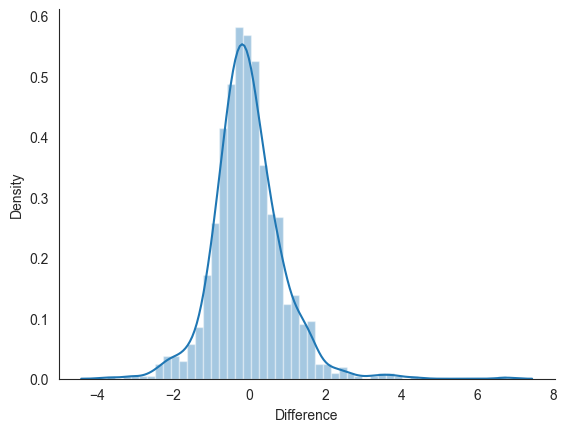

In [29]:
with sns.axes_style('white'):
    sns.distplot(results.Difference)
    sns.despine()

### Evaluate Results

In [30]:
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Agent              1000 non-null   float64
 1   Market             1000 non-null   float64
 2   Difference         1000 non-null   float64
 3   Strategy Wins (%)  901 non-null    float64
dtypes: float64(4)
memory usage: 39.1 KB


The following diagram shows the rolling average of agent and market returns over 100 periods on the left, and the share of the last 100 periods the agent outperformed the market on the right. It uses AAPL stock data for which there are some 9,000 daily price and volume observations. Training stopped after 14,000 trading periods when the agent beat the market 10 consecutive times.

It shows how the agent's performance improves significantly while exploring at a higher rate over the first ~3,000 periods (that is, years) and approaches a level where it outperforms the market around 40 percent of the time, despite transaction costs. In a few instances, it beats the market about half the time out of 100 periods:

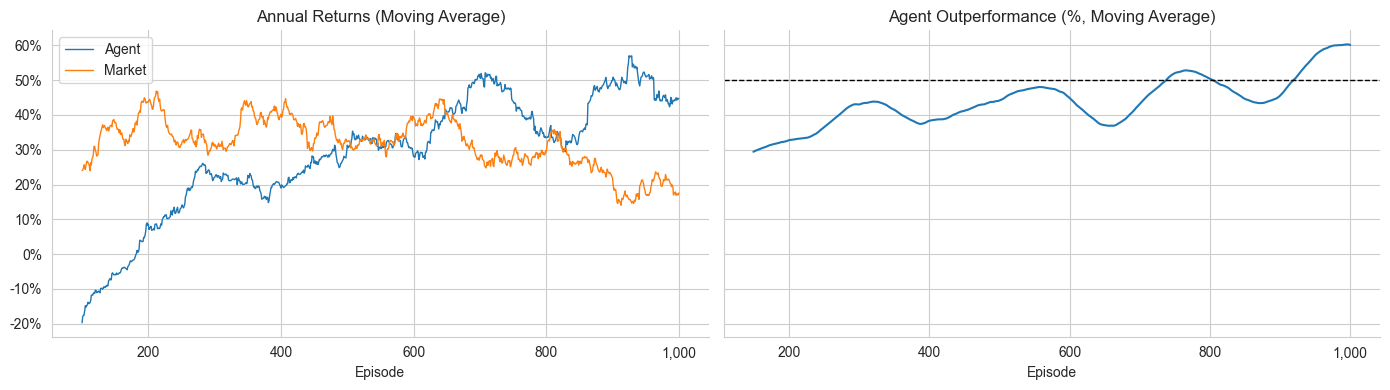

In [31]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)

df1 = (results[['Agent', 'Market']]
       .sub(1)
       .rolling(100)
       .mean())
df1.plot(ax=axes[0],
         title='Annual Returns (Moving Average)',
         lw=1)

df2 = results['Strategy Wins (%)'].div(100).rolling(50).mean()
df2.plot(ax=axes[1],
         title='Agent Outperformance (%, Moving Average)')

for ax in axes:
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))
axes[1].axhline(.5, ls='--', c='k', lw=1)

sns.despine()
fig.tight_layout()
fig.savefig(results_path / 'performance', dpi=300)

## Summary

This relatively simple agent uses limited information beyond the latest market data and the reward signal compared to the machine learning models we covered elsewhere in this book. Nonetheless, it learns to make a profit and approach the market (after training on several thousand year's worth of data, which takes around 30 minutes).

Keep in mind that using a single stock also increase the risk of overfitting the data by a lot. You can test your trained agent on new data using the saved model (see the notebook on the Lunar Lander).

In conclusion, we have demonstrated the mechanics of setting up a RL trading environment and experimented with a basic agent that uses a small number of technical indicators. You should try to extend both the environment and the agent so that you can choose from several assets, size their positions, and manage risks.

More specifically, the environment samples a stock price time series for a single ticker from a random start date to simulate a trading period of 252 days, or 1 year (default). The agent has three options, that is, buying (long), short, or exiting its position, and faces a 10bps trading plus a 1bps time cost per period.